In [1]:
import pennylane as qml
import numpy as np
import matplotlib.pyplot as plt

# Quantum Fourier Transform (QFT)

$$|j\rangle \xrightarrow{\text{QFT}} \frac{1}{\sqrt{N}} \sum_{k=0}^{N-1} e^{2\pi i \frac{jk}{N}} |k\rangle$$

### Quantum circuit for QFT

Note.

Hadamard gate -- $H|0\rangle= \frac{1}{\sqrt{2}}(|0\rangle+|1\rangle)$, $H|1\rangle= \frac{1}{\sqrt{2}}(|0\rangle-|1\rangle)$

PhaseShift gate -- $R_{\phi}(\phi)|0\rangle= |0\rangle$, $R_{\phi}(\phi)|1\rangle= e^{i \phi}|1\rangle$

In [2]:
def circ_qft(wires):
    n = len(wires)
    for i in range(n):
        qml.Hadamard(wires=wires[i])
        for j in range(i+1, n):
            angle = np.pi/(2**(j-i))
            qml.ControlledPhaseShift(angle, wires=[wires[j], wires[i]])

    for i in range(n//2):
        qml.SWAP(wires=[wires[i], wires[n-i-1]])

### Test -- QFT

In [3]:
n_qubits = 4
dev_qft = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev_qft)
def qft_ex():
    circ_qft(wires=range(n_qubits))

In [4]:
drawer = qml.draw(qft_ex)
print("\nCircuit diagram:\n")
print(drawer())


Circuit diagram:

0: ──H─╭Rϕ(1.57)─╭Rϕ(0.79)─╭Rϕ(0.39)────────────────────────────────────────╭SWAP───────┤  
1: ────╰●────────│─────────│──────────H─╭Rϕ(1.57)─╭Rϕ(0.79)─────────────────│─────╭SWAP─┤  
2: ──────────────╰●────────│────────────╰●────────│──────────H─╭Rϕ(1.57)────│─────╰SWAP─┤  
3: ────────────────────────╰●─────────────────────╰●───────────╰●─────────H─╰SWAP───────┤  


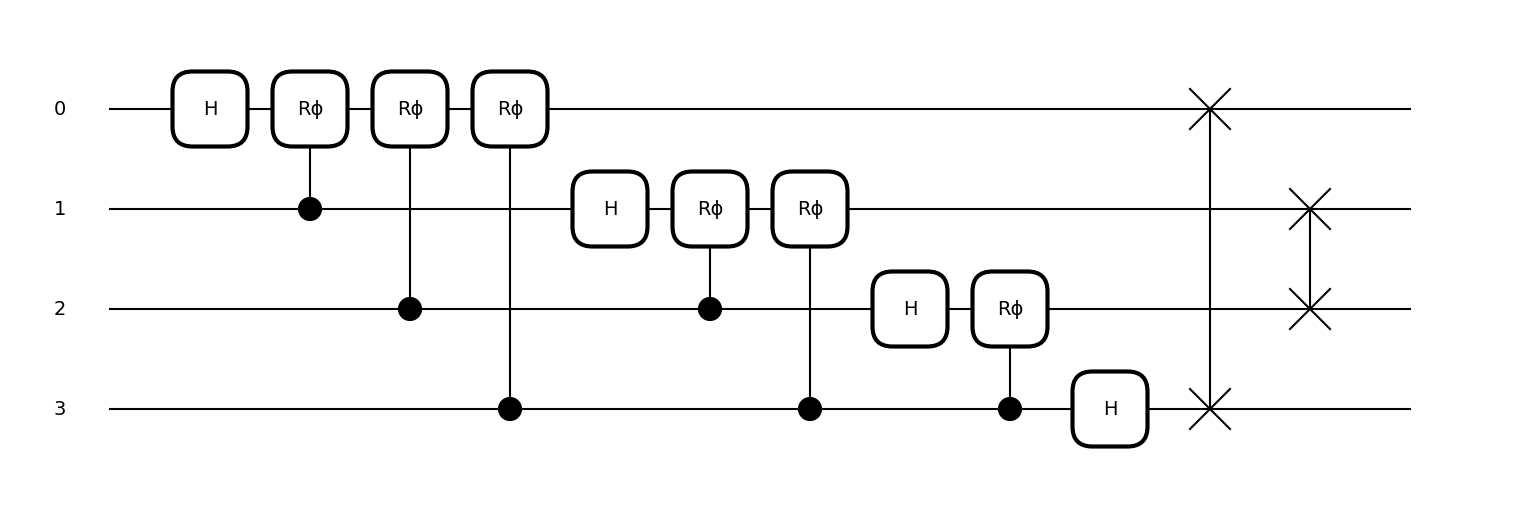

In [5]:
fig, ax = qml.draw_mpl(qft_ex)()
plt.show()

# Quantum Phase Estimation (QPE)

Let
$M=
\begin{pmatrix}
1&0&8&1\\
0&1&1&8\\
8&1&1&0\\
1&8&0&1
\end{pmatrix}$ 
and 
$|v\rangle=\frac{1}{2}\begin{pmatrix}
1\\
1\\
1\\
1
\end{pmatrix}$.

Find $\lambda$ such that $M|v\rangle=\lambda|v\rangle$.

To apply QPE, consider $U=exp(2\pi i*\tilde{M})$, where $\tilde{M}=\frac{1}{16}M$.


In [6]:
from scipy.linalg import expm

M = np.array([
    [1, 0, 8, 1],
    [0, 1, 1, 8],
    [8, 1, 1, 0],
    [1, 8, 0, 1]
], dtype=float)

M_scaled = M / 16
U = expm(2j * np.pi * M_scaled)

### Quantum circuit for inverse QFT

In [7]:
def circ_inv_qft(wires):
    n = len(wires)
    for i in range(n//2):
        qml.SWAP(wires=[wires[i], wires[n-i-1]])
    for i in reversed(range(n)):
        for j in reversed(range(i+1, n)):
            angle = -np.pi/(2**(j-i))
            qml.ControlledPhaseShift(angle, wires=[wires[j], wires[i]])
        qml.Hadamard(wires=wires[i])

### Quantum circuit for QPE

In [8]:
reg_eigval_wires = [0, 1, 2, 3]
reg_eigvec_wires = [4, 5]
n_reg_eigval = len(reg_eigval_wires)
n_reg_eigvec = len(reg_eigvec_wires)

dev_qpe = qml.device("default.qubit", wires=n_reg_eigval+n_reg_eigvec, shots=None)

@qml.qnode(dev_qpe)
def qpe_circuit():
    # Prepare estimation register in uniform superposition
    for w in reg_eigval_wires:
        qml.Hadamard(wires=w)

    # Prepare system register in eigenstate |v> = |++>
    for w in reg_eigvec_wires:
        qml.Hadamard(wires=w)

    # Apply controlled-U^(2^k)
    
    for k in range(n_reg_eigval):
        power = 2**k
        U_k = np.linalg.matrix_power(U, power)
        qml.ctrl(qml.QubitUnitary, control=reg_eigval_wires[n_reg_eigval-1-k])(
            U_k,
            wires=reg_eigvec_wires
        )

    # Inverse QFT on estimation register
    circ_inv_qft(reg_eigval_wires)

    return qml.probs(wires=reg_eigval_wires)

In [9]:
drawer_qpe = qml.draw(qpe_circuit, max_length=300)
print("\nCircuit diagram:\n")
print(drawer_qpe())


Circuit diagram:

0: ──H──────────────────────╭●─────╭SWAP──────────────────────────────────────────────╭Rϕ(-0.39)─╭Rϕ(-0.79)─╭Rϕ(-1.57)──H─┤ ╭Probs
1: ──H───────────────╭●─────│──────│─────╭SWAP───────────────╭Rϕ(-0.79)─╭Rϕ(-1.57)──H─│──────────│──────────╰●────────────┤ ├Probs
2: ──H────────╭●─────│──────│──────│─────╰SWAP─╭Rϕ(-1.57)──H─│──────────╰●────────────│──────────╰●───────────────────────┤ ├Probs
3: ──H─╭●─────│──────│──────│──────╰SWAP──H────╰●────────────╰●───────────────────────╰●──────────────────────────────────┤ ╰Probs
4: ──H─├U(M0)─├U(M1)─├U(M2)─├U(M3)────────────────────────────────────────────────────────────────────────────────────────┤       
5: ──H─╰U(M0)─╰U(M1)─╰U(M2)─╰U(M3)────────────────────────────────────────────────────────────────────────────────────────┤       

M0 = 
[[-8.53553391e-01-3.53553391e-01j -9.70997566e-17-5.01064957e-17j
  -1.86626453e-16+4.37244976e-16j  1.46446609e-01-3.53553391e-01j]
 [-1.67842351e-16-7.97612552e-17j -8.53553391e-01-3.535

In [10]:
probs = qpe_circuit()
print("Probabilities:", probs)

# Print basis states
for idx, p in enumerate(probs):
    bitstring = format(idx, f"0{n_reg_eigval}b")
    if p > 1e-6:
        print(f"{bitstring}: {p:.6f}")

# Decode the most likely phase
idx_max = int(np.argmax(probs))
bitstring_max = format(idx_max, f"0{n_reg_eigval}b")
phase_est = idx_max / (2**n_reg_eigval)
lambda_est = 16 * phase_est

print("\nMost likely bitstring:", bitstring_max)
print("Estimated phase:", phase_est)
print("Estimated eigenvalue of M:", lambda_est)

Probabilities: [1.01463222e-31 7.84003006e-32 6.81217174e-32 7.85101004e-32
 8.85272738e-32 1.12003454e-31 1.49173192e-31 2.43361416e-31
 5.90612100e-31 2.04484440e-30 1.00000000e+00 2.02076218e-30
 5.42003271e-31 2.53191783e-31 1.15468744e-31 1.10388334e-31]
1010: 1.000000

Most likely bitstring: 1010
Estimated phase: 0.625
Estimated eigenvalue of M: 10.0


# HHL Algorithm

Let
$A=
\begin{pmatrix}
2.5&-0.5&-1&0\\
-0.5&-1&0&2.5\\
-1&0&2.5&-0.5\\
0&2.5&-0.5&-1
\end{pmatrix}$ 
and 
$|b\rangle=\begin{pmatrix}
1\\
0\\
0\\
0
\end{pmatrix}$.

Calculate $A^{-1}|b\rangle$.

In [11]:
mat_A = [[2.5, -0.5, -1, 0],
         [-0.5, 2.5, 0, -1],
         [-1, 0, 2.5, -0.5],
         [0, -1, -0.5, 2.5]]
vec_b = [1, 0, 0, 0]

mat_A_scaled = np.array(mat_A) / 8


sol = np.linalg.solve(mat_A_scaled, vec_b)
normalized_sol = sol/np.linalg.norm(sol)

print(normalized_sol)


[0.87303787 0.2444506  0.38413666 0.17460757]


### Quantum circuit for HHL algorithm

Note.

RY gate -- $RY(\phi)|0\rangle= cos(\phi/2)|0\rangle+sin(\phi/2)|1\rangle$

In [12]:
from itertools import product

ancilla_wires = [0]
reg_eigval_wires = [1, 2, 3]
reg_eigvec_wires = [4, 5]
n_reg_eigval = len(reg_eigval_wires)
n_reg_eigvec = len(reg_eigvec_wires)

dev_hhl = qml.device("default.qubit", wires=1+n_reg_eigval+n_reg_eigvec, shots=None)

@qml.qnode(dev_hhl)
def hhl_circuit():
    # Prepare estimation register in uniform superposition
    for w in reg_eigval_wires:
        qml.Hadamard(wires=w)

    # Prepare system register in eigenstate |b> = |00>

    # Apply controlled-U^(2^k)
    U = expm(2j * np.pi * mat_A_scaled)
    for k in range(n_reg_eigval):
        power = 2**k
        U_k = np.linalg.matrix_power(U, power)
        qml.ctrl(qml.QubitUnitary, control=reg_eigval_wires[n_reg_eigval-1-k])(
            U_k,
            wires=reg_eigvec_wires
        )

    # Inverse QFT on estimation register
    circ_inv_qft(reg_eigval_wires)

    # multi-controlled RY gates
    for bits in product([0, 1], repeat=n_reg_eigval):
        bitstring = "".join(str(b) for b in bits)
        lam = 0
        for k in range(n_reg_eigval):
            lam += bits[k]/2**(k+1)
        if lam > 0.01:
            theta = 2 * np.arcsin(0.05/lam)
        else:
            theta=0

        qml.ctrl(
            qml.RY,
            control=reg_eigval_wires,
            control_values=list(bits),
        )(theta, wires=ancilla_wires)

    circ_qft(reg_eigval_wires)
    U_dag = expm(-2j * np.pi * mat_A_scaled)
    for k in reversed(range(n_reg_eigval)):
        power = 2**k
        U_dag_k = np.linalg.matrix_power(U_dag, power)
        qml.ctrl(qml.QubitUnitary, control=reg_eigval_wires[n_reg_eigval-1-k])(
            U_dag_k,
            wires=reg_eigvec_wires
        )

    for w in reg_eigval_wires:
        qml.Hadamard(wires=w)

    return qml.state()

In [13]:
drawer_hhl = qml.draw(hhl_circuit, max_length=300)
print("\nCircuit diagram:\n")
print(drawer_hhl())


Circuit diagram:

0: ─────────────────────────────────────────────────────────────────────────╭RY(0.00)─╭RY(0.82)─╭RY(0.40)─╭RY(0.27)─╭RY(0.20)─╭RY(0.16)─╭RY(0.13)─╭RY(0.11)──────────────────────────────────────────────────────────────────────┤  State
1: ──H───────────────╭●─────╭SWAP──────────────────╭Rϕ(-0.79)─╭Rϕ(-1.57)──H─├○────────├○────────├○────────├○────────├●────────├●────────├●────────├●─────────H─╭Rϕ(1.57)─╭Rϕ(0.79)─────────────────╭SWAP─╭●──────H───────────────┤  State
2: ──H────────╭●─────│──────│────────╭Rϕ(-1.57)──H─│──────────╰●────────────├○────────├○────────├●────────├●────────├○────────├○────────├●────────├●───────────╰●────────│──────────H─╭Rϕ(1.57)────│─────│──────╭●──────H────────┤  State
3: ──H─╭●─────│──────│──────╰SWAP──H─╰●────────────╰●───────────────────────╰○────────╰●────────╰○────────╰●────────╰○────────╰●────────╰○────────╰●─────────────────────╰●───────────╰●─────────H─╰SWAP─│──────│──────╭●──────H─┤  State
4: ────├U(M0)─├U(M1)─├U(M2)──────────────────

In [14]:
full_state = hhl_circuit()
print(full_state)
q_sol = full_state[2**(n_reg_eigval + n_reg_eigvec):2**(n_reg_eigval + n_reg_eigvec)+2**n_reg_eigvec]
q_sol = np.array(q_sol)
q_sol = q_sol/np.linalg.norm(q_sol)
print('quantum solution:', q_sol.real)
print('exact solution:', normalized_sol)


[ 9.70592431e-01+8.48603364e-17j -1.67992364e-02+2.98642470e-16j
 -2.24369127e-02+6.50809949e-17j -1.48411427e-02-6.20507274e-17j
 -5.55111512e-17+2.32219411e-17j  6.59194921e-17-3.80687639e-17j
 -3.46944695e-18-5.26759395e-17j -5.81132364e-17-1.29853381e-17j
  1.17756934e-16-7.97257551e-17j -1.16530300e-17-2.13406159e-17j
  1.22663473e-17-1.05000361e-16j  2.45326947e-18-1.03359258e-17j
 -3.92523115e-17-1.99273119e-17j  2.51460120e-17+2.77247734e-17j
 -4.66121199e-17-6.86958255e-18j -2.69859641e-17+3.87294636e-17j
  1.38777878e-16+4.24445485e-18j  7.67615138e-17-3.65568312e-17j
 -8.84708973e-17-1.25470179e-17j  4.38017678e-17+3.94518489e-17j
  0.00000000e+00+1.68174609e-17j -1.25767452e-17-8.93021247e-17j
 -2.94902991e-17+4.63314493e-17j  3.33934269e-17+1.00126153e-17j
 -8.32667268e-17-3.74611261e-17j -2.90566182e-17-2.06752400e-16j
 -3.46944695e-17+5.14679822e-17j -2.55871713e-17+1.08559267e-17j
 -5.55111512e-17-3.55425399e-19j -2.47198095e-17+6.12672888e-17j
  2.42861287e-17+1.221567